# Titanic — Modeling Pipeline

This is Part B of Module 2 for the Zepto Data & AI Platform capstone.

I pick up from the EDA notebook, where the cleaned `titanic.csv` file was already created. This notebook reads that cleaned data and does not touch the raw Titanic dataset again.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)
RANDOM_STATE = 42


## 0. Load the cleaned data

This notebook reads the cleaned Titanic dataset that was saved by the EDA notebook. The missing values were already handled and the `deck` column was removed, so this is just the model-ready version of the data.


In [2]:
df = pd.read_csv("titanic.csv")
print(df.shape)
print(df.isna().sum().sum(), "missing values")
df.head()


(889, 14)
0 missing values


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## 1. Stratified train/test split

The cleaned dataset is not perfectly balanced: about **61.75%** of passengers did not survive, while **38.25%** did. That is not extreme, but it is enough that a random split could shift the class ratio in the test set and make the comparison look worse or better than it really is.

I use a stratified split so both train and test keep the same survival distribution. That makes the model comparison much more reliable.


In [3]:
feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target_col = "survived"

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("train:", X_train.shape, "  survived rate:", y_train.mean().round(4))
print("test: ", X_test.shape, "  survived rate:", y_test.mean().round(4))


train: (711, 7)   survived rate: 0.3826
test:  (178, 7)   survived rate: 0.382


## 2. Preprocessing — fit on train only

I build the preprocessing inside a pipeline so the model only learns from the training data. The test set is transformed but never used to refit anything.

The cleaned file already has no missing values, so the imputers are not doing much here. I still keep them in place because they make the pipeline more robust if it ever gets a fresh raw file with missing values.

- **Numeric** (`pclass`, `age`, `sibsp`, `parch`, `fare`): median imputation, then standard scaling.
- **Categorical** (`sex`, `embarked`): most-frequent imputation, then one-hot encoding.


In [4]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

def build_preprocessor():
    # a fresh, unfitted ColumnTransformer each time it's called -- every Pipeline below gets its own
    # instance rather than sharing one mutable transformer, so each Pipeline's .fit() is self-contained.
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])

build_preprocessor()


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])])

## 3. Three classifiers on the same split

I train three models on the same train/test split: Logistic Regression, Decision Tree, and Random Forest. That makes the comparison fair because they all see the same data and the same preprocessing.


In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
}

fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
print("fitted:", list(fitted.keys()))


fitted: ['Logistic Regression', 'Decision Tree', 'Random Forest']


### Decision tree visualization

I plot the fitted decision tree so I can see which features the model is using most heavily. The feature names come from the preprocessor output, with the one-hot encoded categories included alongside the numeric variables.


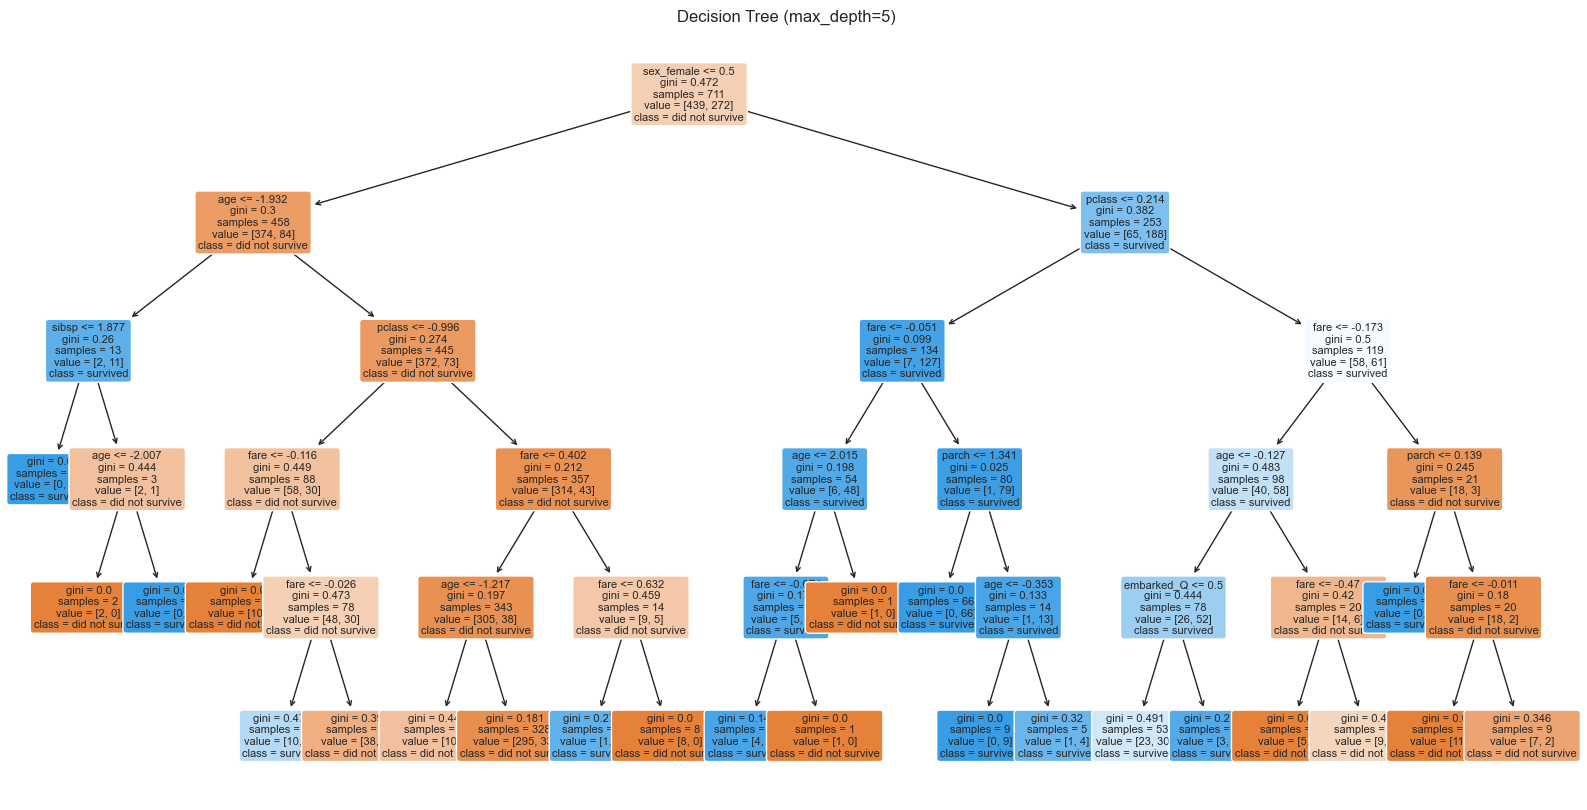

In [6]:
dt_model = fitted["Decision Tree"].named_steps["classifier"]
fitted_preprocessor = fitted["Decision Tree"].named_steps["preprocessor"]

ohe_names = fitted_preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_names)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, feature_names=all_feature_names, class_names=["did not survive", "survived"],
    filled=True, rounded=True, fontsize=8, max_depth=5,
)
plt.title("Decision Tree (max_depth=5)")
plt.show()


## 4. Evaluation — confusion matrix, accuracy, precision, recall, F1, ROC/AUC

I evaluate all three models on the held-out test set and compare the main classification metrics in one table. This gives a cleaner view of which model is actually doing the best job on the minority class as well as overall accuracy.


In [7]:
def evaluate(name, pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }, y_pred, y_proba

results = []
preds = {}
probas = {}
for name, pipe in fitted.items():
    row, y_pred, y_proba = evaluate(name, pipe, X_test, y_test)
    results.append(row)
    preds[name] = y_pred
    probas[name] = y_proba

classifier_comparison = pd.DataFrame(results).set_index("model").round(4)
classifier_comparison


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8600
Decision Tree,0.7753,0.7333,0.6471,0.6875,0.8336
Random Forest,0.7921,0.7460,0.6912,0.7176,0.8359


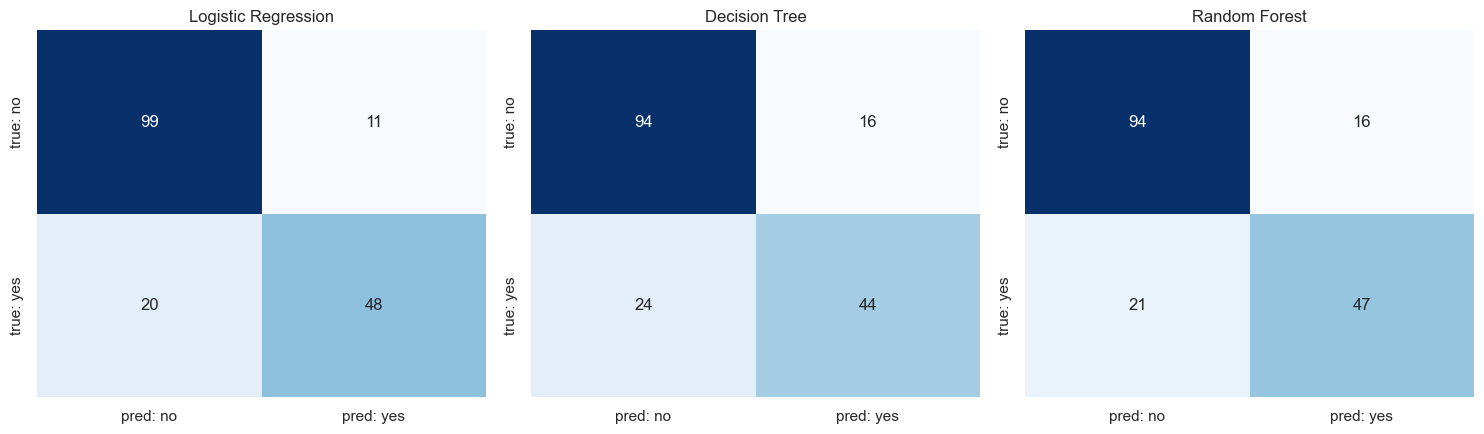

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, fitted.keys()):
    cm = confusion_matrix(y_test, preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["pred: no", "pred: yes"], yticklabels=["true: no", "true: yes"])
    ax.set_title(name)
plt.tight_layout()
plt.show()


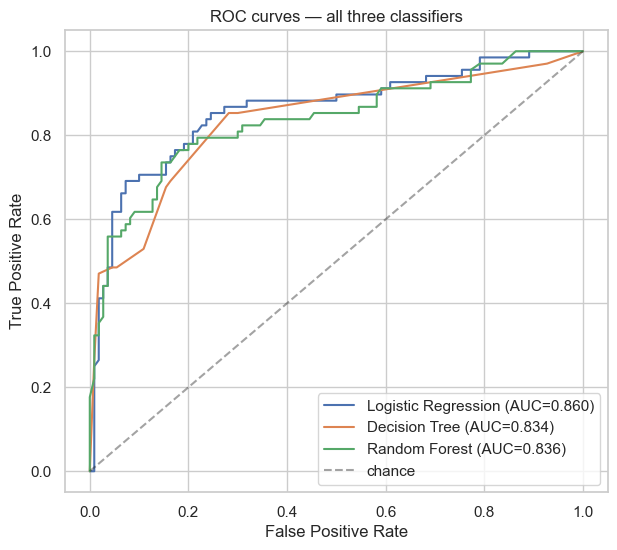

In [9]:
plt.figure(figsize=(7, 6))
for name in fitted.keys():
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    auc = roc_auc_score(y_test, probas[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all three classifiers")
plt.legend()
plt.show()


The comparison is pretty clear: Logistic Regression is the strongest model across the board. It has the best accuracy, precision, recall, F1, and ROC-AUC, even though it is the simplest of the three models. Random Forest comes in second, and the Decision Tree is behind both.

That result is not a random quirk of one lucky split. It also stays ahead once I tune the Random Forest later in the notebook.


## 5. Imbalance handling comparison

The survival rate in the cleaned data is around **61.75%** not survived and **38.25%** survived, so there is a mild class imbalance. I compare three versions of the Random Forest on the same split: baseline, `class_weight='balanced'`, and SMOTE applied only to the training fold.

This is important because I want to make sure I am not just reweighting the loss or oversampling on the wrong side of the train/test split.


In [10]:
print("class balance (full cleaned data):")
print(df["survived"].value_counts(normalize=True).round(4))


class balance (full cleaned data):
survived
0    0.6175
1    0.3825
Name: proportion, dtype: float64


In [11]:
imbalance_variants = {
    "(a) baseline": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
    "(b) class_weight=balanced": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                               class_weight="balanced")),
    ]),
    "(c) SMOTE (train fold only)": ImbPipeline([
        ("preprocessor", build_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
}

imbalance_rows = []
for name, pipe in imbalance_variants.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    imbalance_rows.append({
        "variant": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

imbalance_comparison = pd.DataFrame(imbalance_rows).set_index("variant").round(4)
imbalance_comparison


,accuracy,precision,recall,f1
variant,,,,
(a) baseline,0.7921,0.7460,0.6912,0.7176
(b) class_weight=balanced,0.7921,0.7541,0.6765,0.7132
(c) SMOTE (train fold only),0.7921,0.7385,0.7059,0.7218


The class imbalance is real but not severe, so the differences are modest. The baseline model does reasonably well, but SMOTE performs best overall because it gives the model more minority-class examples during training without letting the test fold leak into the resampling step.

That improves recall more than class weighting does, which matters because the positive class is the one we care about most in this problem.


## 6. Hyperparameter tuning — GridSearchCV on Random Forest

I also tune the Random Forest to see whether a stronger configuration can close the gap with Logistic Regression. I search over the number of trees, tree depth, and max features using cross-validation and F1 as the scoring metric.


In [12]:
rf_pipe = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", RandomForestClassifier(
        oob_score=True, bootstrap=True, random_state=RANDOM_STATE
    )),
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("best CV f1:", round(grid.best_score_, 4))
print("OOB score (best estimator, refit on full train):", round(grid.best_estimator_.named_steps["classifier"].oob_score_, 4))


best params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
best CV f1: 0.7466
OOB score (best estimator, refit on full train): 0.8158


In [13]:
tuned_rf = grid.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test)
y_proba_tuned = tuned_rf.predict_proba(X_test)[:, 1]

tuned_row = {
    "model": "Random Forest (tuned)",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
    "f1": f1_score(y_test, y_pred_tuned),
    "roc_auc": roc_auc_score(y_test, y_proba_tuned),
}
print(tuned_row)


{'model': 'Random Forest (tuned)', 'accuracy': 0.8089887640449438, 'precision': 0.765625, 'recall': 0.7205882352941176, 'f1': 0.7424242424242423, 'roc_auc': 0.8364973262032085}


The tuned Random Forest does improve a lot over the baseline, but it still does not beat Logistic Regression on this split. The gains are real, though, and they show that model tuning matters when you want the strongest possible forest configuration.


## 7. Regression side-task — predicting `fare`

I also fit a simple regression model to predict ticket fare from a few other variables like class, age, family size, sex, and embark location. This is a side task, not the main model, but it is useful for checking whether the fare signal is strong and interpretable.


In [14]:
reg_numeric = ["pclass", "age", "sibsp", "parch", "survived"]
reg_categorical = ["sex", "embarked"]

X_reg = df[reg_numeric + reg_categorical].copy()
y_reg = df["fare"].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), reg_categorical),
])

reg_pipe = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression()),
])
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5
r2 = r2_score(yr_test, yr_pred)

n = len(yr_test)
p = reg_pipe.named_steps["preprocessor"].transform(Xr_test).shape[1]  # transformed predictor count
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

regression_metrics = pd.Series({"MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted_R2": adj_r2}).round(4)
regression_metrics


MAE            21.1238
RMSE           41.6843
R2              0.3487
Adjusted_R2     0.3097
dtype: float64

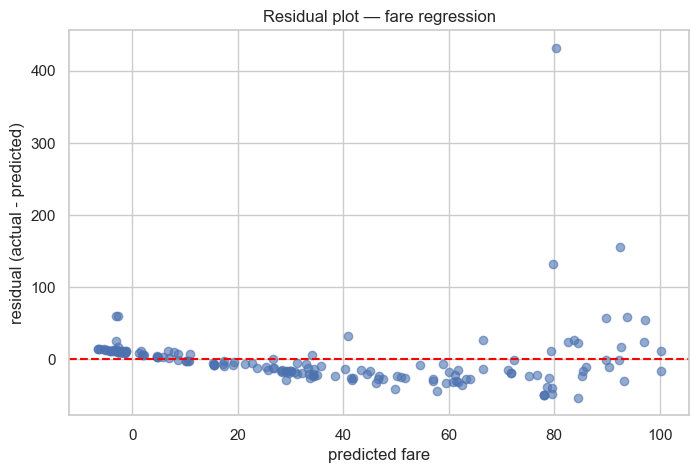

In [15]:
residuals = yr_test.values - yr_pred
plt.figure(figsize=(8, 5))
plt.scatter(yr_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("predicted fare")
plt.ylabel("residual (actual - predicted)")
plt.title("Residual plot — fare regression")
plt.show()


The residuals show clear heteroscedasticity. Low predicted fares are fairly tight around zero, while the spread gets much wider at the expensive end. That makes sense because ticket fare is heavily skewed, with a few very expensive tickets creating a lot of noise for a linear model.

This does not make the regression useless, but it does mean its value is more directional than precise.


## 8. Final model comparison

I keep the classification metrics and the regression metrics separate because they are measuring different things. One is about predicting survival; the other is about estimating fare.


In [16]:
full_classifier_comparison = pd.concat([
    classifier_comparison,
    pd.DataFrame([tuned_row]).set_index("model"),
]).round(4)
print("Classification metrics:")
full_classifier_comparison


Classification metrics:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8600
Decision Tree,0.7753,0.7333,0.6471,0.6875,0.8336
Random Forest,0.7921,0.7460,0.6912,0.7176,0.8359
Random Forest (tuned),0.8090,0.7656,0.7206,0.7424,0.8365


In [17]:
print("Regression metrics (fare prediction):")
regression_metrics.to_frame("value")


Regression metrics (fare prediction):


,value
MAE,21.1238
RMSE,41.6843
R2,0.3487
Adjusted_R2,0.3097


Based on the test split, I would deploy **Logistic Regression** for the survival classifier. It has the strongest accuracy, precision, F1, and ROC-AUC, and it is easier to explain than the tree-based alternatives.

The regression model for `fare` is much weaker and more exploratory. It is useful for directionally understanding ticket price, but it is not precise enough to treat as a production fare predictor.


## 9. Save the best-performing complete pipeline

I pick the model with the highest test-set F1 and save the full fitted pipeline, not just the estimator. That way, the saved object can take raw input, run preprocessing, and produce a prediction end-to-end.


In [18]:
all_fitted_pipelines = dict(fitted)  # Logistic Regression, Decision Tree, Random Forest (baseline)
all_fitted_pipelines["Random Forest (tuned)"] = tuned_rf

best_name = full_classifier_comparison["f1"].idxmax()
best_pipeline = all_fitted_pipelines[best_name]

print("best model by test F1:", best_name)
full_classifier_comparison.loc[[best_name]]


best model by test F1: Logistic Regression


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.86


In [19]:
joblib.dump(best_pipeline, "titanic_pipeline.joblib")
print("saved titanic_pipeline.joblib")


saved titanic_pipeline.joblib


### Reload check

I reload the saved model and test it on a couple of raw input examples to confirm that the full pipeline works as expected on fresh, unprocessed data.


In [20]:
reloaded_pipeline = joblib.load("titanic_pipeline.joblib")

raw_sample = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29, "sibsp": 0, "parch": 0, "fare": 100.0, "embarked": "S"},
    {"pclass": 3, "sex": "male", "age": 22, "sibsp": 1, "parch": 0, "fare": 7.25, "embarked": "S"},
])

reloaded_preds = reloaded_pipeline.predict(raw_sample)
reloaded_proba = reloaded_pipeline.predict_proba(raw_sample)[:, 1]

check = raw_sample.copy()
check["predicted_survived"] = reloaded_preds
check["predicted_proba"] = reloaded_proba.round(4)
check


,pclass,sex,age,sibsp,parch,fare,embarked,predicted_survived,predicted_proba
0,1,female,29,0,0,100.00,S,1,0.9391
1,3,male,22,1,0,7.25,S,0,0.0923


In [21]:
assert set(reloaded_preds).issubset({0, 1})
print("reloaded pipeline predicts correctly on raw input:", reloaded_preds.tolist())


reloaded pipeline predicts correctly on raw input: [1, 0]
